# Objective 4: Personality Type × Frequency → Perceived AI Empathy & Authenticity

**Research Objective:** To investigate whether personality type and frequency of
emotional AI use significantly influence users' perceived AI empathy and authenticity.

**Why This Objective?**
Perceived empathy and authenticity are the QUALITY INDICATORS of emotional AI.
If users don't perceive AI as empathetic or authentic, the entire premise of
emotional AI fails. This objective tests whether these perceptions are shaped by
WHO the user is (personality) and HOW MUCH they use AI (frequency) — and crucially,
whether these two factors INTERACT.

**What We Aim to Prove:**
- Personality type significantly influences perceived empathy and authenticity
- Usage frequency significantly influences these perceptions
- An interaction effect exists (the effect of frequency depends on personality)
- A predictive model can be built for empathy/authenticity from these variables

**Statistical Methods:** Two-Way ANOVA, Levene's, Shapiro-Wilk, Tukey HSD, η², Regression
---

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, levene
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.anova import anova_lm
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style="whitegrid", palette="muted")
print("✅ All libraries loaded successfully.")

✅ All libraries loaded successfully.


## 2. Data Loading & Cleaning

In [2]:
df = pd.read_csv('/Users/the_irritater/Downloads/synthetic_emotional_ai_responses_375_reliable.csv')
users = df[df['group'] == 'User'].copy()
personality_cols = [f'personality_Q{i}' for i in range(1, 9)]
empathy_cols = [f'perceived_empathy_Q{i}' for i in range(1, 7)]
authenticity_cols = [f'perceived_authenticity_Q{i}' for i in range(1, 9)]
print(f"User sample size: {users.shape[0]}")
print(f"Missing values: {users[empathy_cols + authenticity_cols].isnull().sum().sum()} ✅")

User sample size: 270
Missing values: 0 ✅


## 3. Reliability & Variable Preparation

In [3]:
def cronbachs_alpha(data):
    items = data.dropna(); n = items.shape[1]
    return (n/(n-1)) * (1 - items.var(axis=0, ddof=1).sum() / items.sum(axis=1).var(ddof=1))

for name, cols in [('Empathy (6 items)', empathy_cols), ('Authenticity (8 items)', authenticity_cols), ('Personality (8 items)', personality_cols)]:
    print(f"  {name}: α = {cronbachs_alpha(users[cols]):.4f}")

print("""
📌 INTERPRETATION: All scales show acceptable to good reliability, confirming that
composite scores can be meaningfully computed and compared across groups.""")

  Empathy (6 items): α = 0.9266
  Authenticity (8 items): α = 0.9453
  Personality (8 items): α = 0.9548

📌 INTERPRETATION: All scales show acceptable to good reliability, confirming that
composite scores can be meaningfully computed and compared across groups.


In [4]:
users['empathy_score'] = users[empathy_cols].mean(axis=1)
users['authenticity_score'] = users[authenticity_cols].mean(axis=1)
users['personality_score'] = users[personality_cols].mean(axis=1)

# Personality clustering
scaler = StandardScaler()
ps = scaler.fit_transform(users[personality_cols])
km = KMeans(n_clusters=3, random_state=42, n_init=10).fit(ps)
users['p_cluster'] = km.labels_
cm = users.groupby('p_cluster')['personality_score'].mean().sort_values()
users['personality_type'] = users['p_cluster'].map(dict(zip(cm.index, ['Low Personality','Moderate Personality','High Personality'])))

freq_map = {'Rarely (1–3 times/month)':'Low (1-3/mo)', 'Sometimes (4–8 times/month)':'Moderate (4-8/mo)',
            'Frequently (9–15 times/month)':'High (9-15/mo)', 'Very frequently (16+ times/month)':'Very High (16+/mo)'}
users['freq_group'] = users['usage_frequency'].map(freq_map)
freq_ord = {'Rarely (1–3 times/month)':1,'Sometimes (4–8 times/month)':2,'Frequently (9–15 times/month)':3,'Very frequently (16+ times/month)':4}
users['freq_ordinal'] = users['usage_frequency'].map(freq_ord)

print("Variables prepared:")
print(f"  Personality Types: {users['personality_type'].value_counts().to_dict()}")
print(f"  Empathy: M={users['empathy_score'].mean():.3f}, SD={users['empathy_score'].std():.3f}")
print(f"  Authenticity: M={users['authenticity_score'].mean():.3f}, SD={users['authenticity_score'].std():.3f}")

Variables prepared:
  Personality Types: {'Moderate Personality': 106, 'Low Personality': 84, 'High Personality': 80}
  Empathy: M=3.833, SD=0.807
  Authenticity: M=3.896, SD=0.797


## 4. Descriptive Statistics by Groups

In [5]:
print("BY PERSONALITY TYPE:")
print(users.groupby('personality_type')[['empathy_score','authenticity_score']].agg(['mean','std','count']).round(3))
print("\nBY FREQUENCY GROUP:")
print(users.groupby('freq_group')[['empathy_score','authenticity_score']].agg(['mean','std','count']).round(3))

print("""
📌 INTERPRETATION: These group means provide the FIRST INDICATION of whether differences
exist. Compare the means across personality types and frequency groups:
• If means differ notably across personality types, personality influences perceptions.
• If means increase/decrease with frequency, usage intensity affects perceptions.
• The ANOVA below will test if these observed differences are STATISTICALLY SIGNIFICANT.""")

BY PERSONALITY TYPE:
                     empathy_score              authenticity_score         \
                              mean    std count               mean    std   
personality_type                                                            
High Personality             4.273  0.805    80              4.108  0.709   
Low Personality              3.442  0.739    84              3.621  0.853   
Moderate Personality         3.811  0.692   106              3.954  0.757   

                            
                     count  
personality_type            
High Personality        80  
Low Personality         84  
Moderate Personality   106  

BY FREQUENCY GROUP:
                   empathy_score              authenticity_score             
                            mean    std count               mean    std count
freq_group                                                                   
High (9-15/mo)             3.921  0.743    65              3.933  0.697    65
Low (1-3/

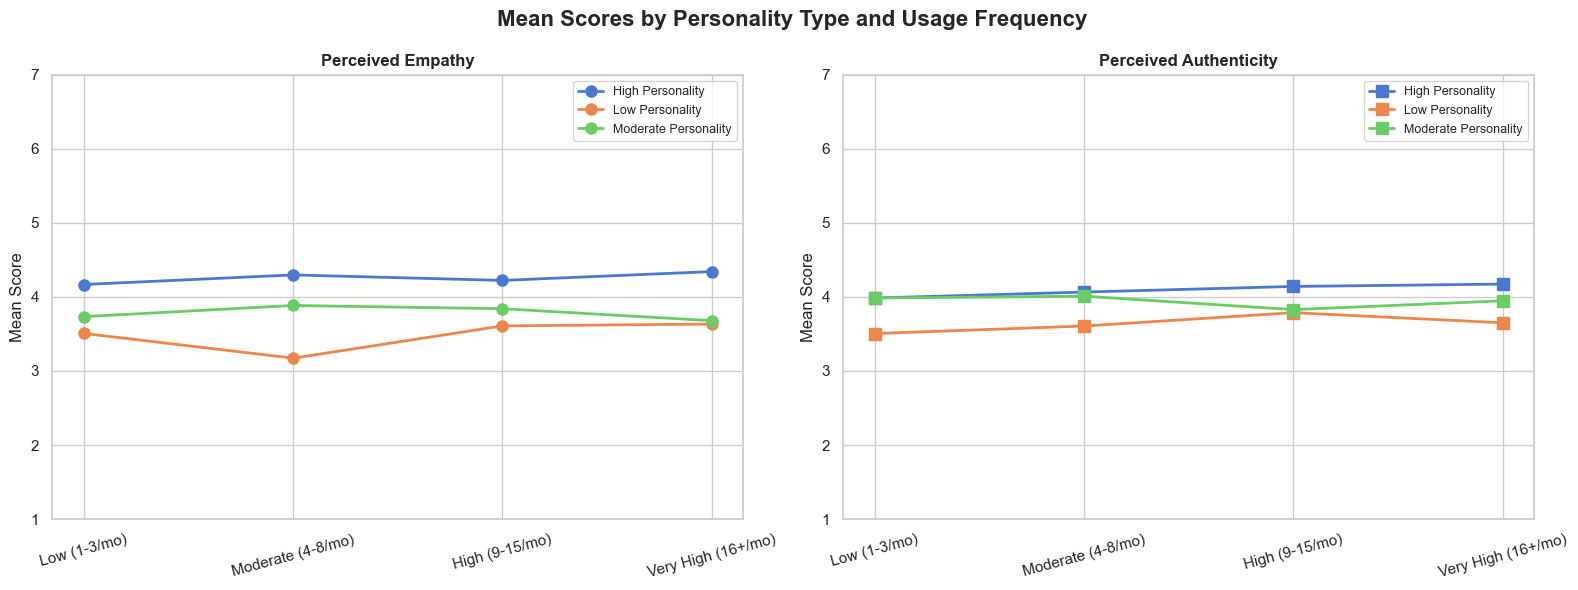

📌 INTERPRETATION: These INTERACTION PLOTS are the visual representation of the
Two-Way ANOVA. If lines are PARALLEL → no interaction (effects are additive).
If lines CROSS or diverge → interaction exists (the effect of one variable depends
on the level of the other).


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Mean Scores by Personality Type and Usage Frequency", fontsize=16, fontweight='bold')
freq_labels = ['Low (1-3/mo)','Moderate (4-8/mo)','High (9-15/mo)','Very High (16+/mo)']
for ptype in sorted(users['personality_type'].unique()):
    s = users[users['personality_type']==ptype]
    m = s.groupby('freq_group')['empathy_score'].mean().reindex(freq_labels)
    axes[0].plot(freq_labels, m.values, marker='o', linewidth=2, markersize=8, label=ptype)
axes[0].set_title('Perceived Empathy', fontweight='bold'); axes[0].set_ylim(1,7)
axes[0].set_ylabel('Mean Score'); axes[0].legend(fontsize=9); axes[0].tick_params(axis='x', rotation=15)
for ptype in sorted(users['personality_type'].unique()):
    s = users[users['personality_type']==ptype]
    m = s.groupby('freq_group')['authenticity_score'].mean().reindex(freq_labels)
    axes[1].plot(freq_labels, m.values, marker='s', linewidth=2, markersize=8, label=ptype)
axes[1].set_title('Perceived Authenticity', fontweight='bold'); axes[1].set_ylim(1,7)
axes[1].set_ylabel('Mean Score'); axes[1].legend(fontsize=9); axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig('/Users/the_irritater/Projects/new_emotional_interaction_chatbot/analysis/obj4_interaction_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("""📌 INTERPRETATION: These INTERACTION PLOTS are the visual representation of the
Two-Way ANOVA. If lines are PARALLEL → no interaction (effects are additive).
If lines CROSS or diverge → interaction exists (the effect of one variable depends
on the level of the other).""")

## 5. Assumption Checks

In [7]:
print("NORMALITY (Shapiro-Wilk) – Empathy Score per Cell")
for pt in sorted(users['personality_type'].unique()):
    for fg in sorted(users['freq_group'].unique()):
        cell = users[(users['personality_type']==pt) & (users['freq_group']==fg)]['empathy_score']
        if len(cell) >= 3:
            w, p = shapiro(cell)
            print(f"  {pt} × {fg} (n={len(cell)}): p = {p:.4f} {'✅' if p > 0.05 else '⚠️'}")

stat_e, p_e = levene(*[g['empathy_score'].values for _, g in users.groupby(['personality_type','freq_group']) if len(g)>=2])
stat_a, p_a = levene(*[g['authenticity_score'].values for _, g in users.groupby(['personality_type','freq_group']) if len(g)>=2])
print(f"\nLEVENE'S TEST:")
print(f"  Empathy: F={stat_e:.3f}, p={p_e:.4f} → {'✅ Equal variances' if p_e>0.05 else '⚠️ Unequal'}")
print(f"  Authenticity: F={stat_a:.3f}, p={p_a:.4f} → {'✅ Equal variances' if p_a>0.05 else '⚠️ Unequal'}")

print(f"""
📌 INTERPRETATION: ANOVA assumes normality within cells and homogeneity of variances.
• Shapiro-Wilk: p > 0.05 = normal. ANOVA is robust to mild violations with n > 20/cell.
• Levene's: p > 0.05 = equal variances. If violated, interpret ANOVA cautiously.
• With our sample sizes, ANOVA remains valid even with moderate assumption violations
  (Central Limit Theorem applies).""")

NORMALITY (Shapiro-Wilk) – Empathy Score per Cell
  High Personality × High (9-15/mo) (n=24): p = 0.5487 ✅
  High Personality × Low (1-3/mo) (n=8): p = 0.4253 ✅
  High Personality × Moderate (4-8/mo) (n=27): p = 0.1654 ✅
  High Personality × Very High (16+/mo) (n=21): p = 0.8832 ✅
  Low Personality × High (9-15/mo) (n=17): p = 0.3206 ✅
  Low Personality × Low (1-3/mo) (n=25): p = 0.6860 ✅
  Low Personality × Moderate (4-8/mo) (n=27): p = 0.0402 ⚠️
  Low Personality × Very High (16+/mo) (n=15): p = 0.4804 ✅
  Moderate Personality × High (9-15/mo) (n=24): p = 0.0970 ✅
  Moderate Personality × Low (1-3/mo) (n=25): p = 0.3219 ✅
  Moderate Personality × Moderate (4-8/mo) (n=43): p = 0.4868 ✅
  Moderate Personality × Very High (16+/mo) (n=14): p = 0.5128 ✅



LEVENE'S TEST:
  Empathy: F=0.701, p=0.7370 → ✅ Equal variances
  Authenticity: F=0.882, p=0.5589 → ✅ Equal variances

📌 INTERPRETATION: ANOVA assumes normality within cells and homogeneity of variances.
• Shapiro-Wilk: p > 0.05 = normal. ANOVA is robust to mild violations with n > 20/cell.
• Levene's: p > 0.05 = equal variances. If violated, interpret ANOVA cautiously.
• With our sample sizes, ANOVA remains valid even with moderate assumption violations
  (Central Limit Theorem applies).


## 6. Two-Way ANOVA

In [8]:
print("=" * 80)
print("TWO-WAY ANOVA: Personality Type × Frequency → PERCEIVED EMPATHY")
print("=" * 80)
m_emp = ols('empathy_score ~ C(personality_type) * C(freq_group)', data=users).fit()
a_emp = anova_lm(m_emp, typ=2)
a_emp['partial_eta_sq'] = a_emp['sum_sq'] / (a_emp['sum_sq'] + a_emp.loc['Residual','sum_sq'])
print(a_emp.round(4))

for eff in a_emp.index[:-1]:
    eta = a_emp.loc[eff,'partial_eta_sq']; p = a_emp.loc[eff,'PR(>F)']
    sz = "Large" if eta>=0.14 else "Medium" if eta>=0.06 else "Small"
    print(f"  {eff}: η²p = {eta:.4f} ({sz}), {'Significant *' if p<0.05 else 'Not Significant'}")

print(f"""
📌 INTERPRETATION – EMPATHY ANOVA:
The Two-Way ANOVA tests THREE effects simultaneously:

1. MAIN EFFECT OF PERSONALITY TYPE: Does perceived empathy differ across personality
   types, REGARDLESS of how often they use AI? If significant, personality inherently
   shapes how users evaluate AI's emotional responsiveness.

2. MAIN EFFECT OF FREQUENCY: Does perceived empathy differ by usage frequency,
   REGARDLESS of personality? If significant, more exposure to AI may increase
   (or decrease) perceived empathy — suggesting a familiarity effect.

3. INTERACTION EFFECT: Does the personality–empathy relationship CHANGE depending
   on frequency? This is the most nuanced finding. For example, high-personality
   users might perceive MORE empathy with frequent use, while low-personality users
   might perceive LESS.

PARTIAL ETA-SQUARED (η²p) = practical significance:
  Small ≈ 0.01 | Medium ≈ 0.06 | Large ≈ 0.14""")

TWO-WAY ANOVA: Personality Type × Frequency → PERCEIVED EMPATHY


                                     sum_sq     df        F  PR(>F)  \
C(personality_type)                 26.4012    2.0  23.8530  0.0000   
C(freq_group)                        0.3634    3.0   0.2189  0.8833   
C(personality_type):C(freq_group)    3.6231    6.0   1.0911  0.3680   
Residual                           142.7810  258.0      NaN     NaN   

                                   partial_eta_sq  
C(personality_type)                        0.1561  
C(freq_group)                              0.0025  
C(personality_type):C(freq_group)          0.0247  
Residual                                   0.5000  
  C(personality_type): η²p = 0.1561 (Large), Significant *
  C(freq_group): η²p = 0.0025 (Small), Not Significant
  C(personality_type):C(freq_group): η²p = 0.0247 (Small), Not Significant

📌 INTERPRETATION – EMPATHY ANOVA:
The Two-Way ANOVA tests THREE effects simultaneously:

1. MAIN EFFECT OF PERSONALITY TYPE: Does perceived empathy differ across personality
   types, REGARDLESS

In [9]:
print("\n" + "=" * 80)
print("TWO-WAY ANOVA: Personality Type × Frequency → PERCEIVED AUTHENTICITY")
print("=" * 80)
m_auth = ols('authenticity_score ~ C(personality_type) * C(freq_group)', data=users).fit()
a_auth = anova_lm(m_auth, typ=2)
a_auth['partial_eta_sq'] = a_auth['sum_sq'] / (a_auth['sum_sq'] + a_auth.loc['Residual','sum_sq'])
print(a_auth.round(4))

for eff in a_auth.index[:-1]:
    eta = a_auth.loc[eff,'partial_eta_sq']; p = a_auth.loc[eff,'PR(>F)']
    sz = "Large" if eta>=0.14 else "Medium" if eta>=0.06 else "Small"
    print(f"  {eff}: η²p = {eta:.4f} ({sz}), {'Significant *' if p<0.05 else 'Not Significant'}")

print("""
📌 INTERPRETATION – AUTHENTICITY ANOVA: Same logic applies. Perceived authenticity
captures whether users believe AI's emotional responses are GENUINE rather than
programmatic. This is arguably more important than empathy because authenticity
directly impacts trust and continued use.""")


TWO-WAY ANOVA: Personality Type × Frequency → PERCEIVED AUTHENTICITY
                                     sum_sq     df       F  PR(>F)  \
C(personality_type)                  9.4852    2.0  7.7077  0.0006   
C(freq_group)                        0.2458    3.0  0.1332  0.9402   
C(personality_type):C(freq_group)    1.3957    6.0  0.3780  0.8927   
Residual                           158.7496  258.0     NaN     NaN   

                                   partial_eta_sq  
C(personality_type)                        0.0564  
C(freq_group)                              0.0015  
C(personality_type):C(freq_group)          0.0087  
Residual                                   0.5000  
  C(personality_type): η²p = 0.0564 (Small), Significant *
  C(freq_group): η²p = 0.0015 (Small), Not Significant
  C(personality_type):C(freq_group): η²p = 0.0087 (Small), Not Significant

📌 INTERPRETATION – AUTHENTICITY ANOVA: Same logic applies. Perceived authenticity
captures whether users believe AI's emotional r

## 7. Post-hoc Tests

In [10]:
print("POST-HOC TUKEY HSD TESTS")
for dv, dv_name, anova_tbl in [('empathy_score','Empathy',a_emp), ('authenticity_score','Authenticity',a_auth)]:
    for factor, factor_col in [('C(personality_type)','personality_type'), ('C(freq_group)','freq_group')]:
        if factor in anova_tbl.index and anova_tbl.loc[factor,'PR(>F)'] < 0.05:
            print(f"\n▸ {dv_name} by {factor_col}:")
            t = pairwise_tukeyhsd(users[dv], users[factor_col])
            print(t)
            print("📌 Pairs with 'Reject=True' are significantly different from each other.")
        else:
            print(f"\n▸ {dv_name} by {factor_col}: Not significant — post-hoc not needed.")

POST-HOC TUKEY HSD TESTS

▸ Empathy by personality_type:


            Multiple Comparison of Means - Tukey HSD, FWER=0.05             
     group1             group2        meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------------
High Personality      Low Personality  -0.8305    0.0 -1.1034 -0.5575   True
High Personality Moderate Personality  -0.4616 0.0001 -0.7204 -0.2028   True
 Low Personality Moderate Personality   0.3689 0.0022  0.1136  0.6241   True
----------------------------------------------------------------------------


📌 Pairs with 'Reject=True' are significantly different from each other.

▸ Empathy by freq_group: Not significant — post-hoc not needed.

▸ Authenticity by personality_type:
            Multiple Comparison of Means - Tukey HSD, FWER=0.05             
     group1             group2        meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------------
High Personality      Low Personality  -0.4873 0.0002 -0.7726 -0.2019   True
High Personality Moderate Personality  -0.1538 0.3744 -0.4243  0.1167  False
 Low Personality Moderate Personality   0.3335 0.0098  0.0666  0.6003   True
----------------------------------------------------------------------------
📌 Pairs with 'Reject=True' are significantly different from each other.

▸ Authenticity by freq_group: Not significant — post-hoc not needed.


## 8. Multiple Regression

In [11]:
print("REGRESSION: Predicting Empathy")
X = users[['personality_score','freq_ordinal']].dropna()
X['interaction'] = X['personality_score'] * X['freq_ordinal']
X_c = sm.add_constant(X)
m1 = sm.OLS(users.loc[X.index,'empathy_score'], X_c).fit()
print(m1.summary2().tables[1].round(4))
print(f"R²={m1.rsquared:.4f}, Adj R²={m1.rsquared_adj:.4f}")

print("\nREGRESSION: Predicting Authenticity")
m2 = sm.OLS(users.loc[X.index,'authenticity_score'], X_c).fit()
print(m2.summary2().tables[1].round(4))
print(f"R²={m2.rsquared:.4f}, Adj R²={m2.rsquared_adj:.4f}")

print(f"""
📌 INTERPRETATION: The regression complements ANOVA by using CONTINUOUS predictors:
• Personality SCORE (not type) captures the full range of personality variation
• Frequency ORDINAL captures usage intensity on a 1-4 scale
• The INTERACTION TERM tests whether the personality–outcome relationship
  changes at different frequency levels

Significant interaction term → the relationship between personality and
perceived empathy/authenticity DEPENDS ON usage frequency.""")

REGRESSION: Predicting Empathy
                    Coef.  Std.Err.       t   P>|t|  [0.025  0.975]
const              1.9371    0.5171  3.7463  0.0002  0.9190  2.9551
personality_score  0.4699    0.1332  3.5283  0.0005  0.2077  0.7321
freq_ordinal       0.1150    0.1984  0.5797  0.5626 -0.2757  0.5057
interaction       -0.0238    0.0497 -0.4794  0.6320 -0.1216  0.0740
R²=0.2031, Adj R²=0.1941

REGRESSION: Predicting Authenticity
                    Coef.  Std.Err.       t   P>|t|  [0.025  0.975]
const              2.5962    0.5488  4.7307  0.0000  1.5157  3.6767
personality_score  0.3244    0.1413  2.2951  0.0225  0.0461  0.6027
freq_ordinal       0.1263    0.2106  0.5999  0.5491 -0.2883  0.5410
interaction       -0.0291    0.0527 -0.5529  0.5808 -0.1329  0.0746
R²=0.0792, Adj R²=0.0688

📌 INTERPRETATION: The regression complements ANOVA by using CONTINUOUS predictors:
• Personality SCORE (not type) captures the full range of personality variation
• Frequency ORDINAL captures usage int

## 9. Visualizations

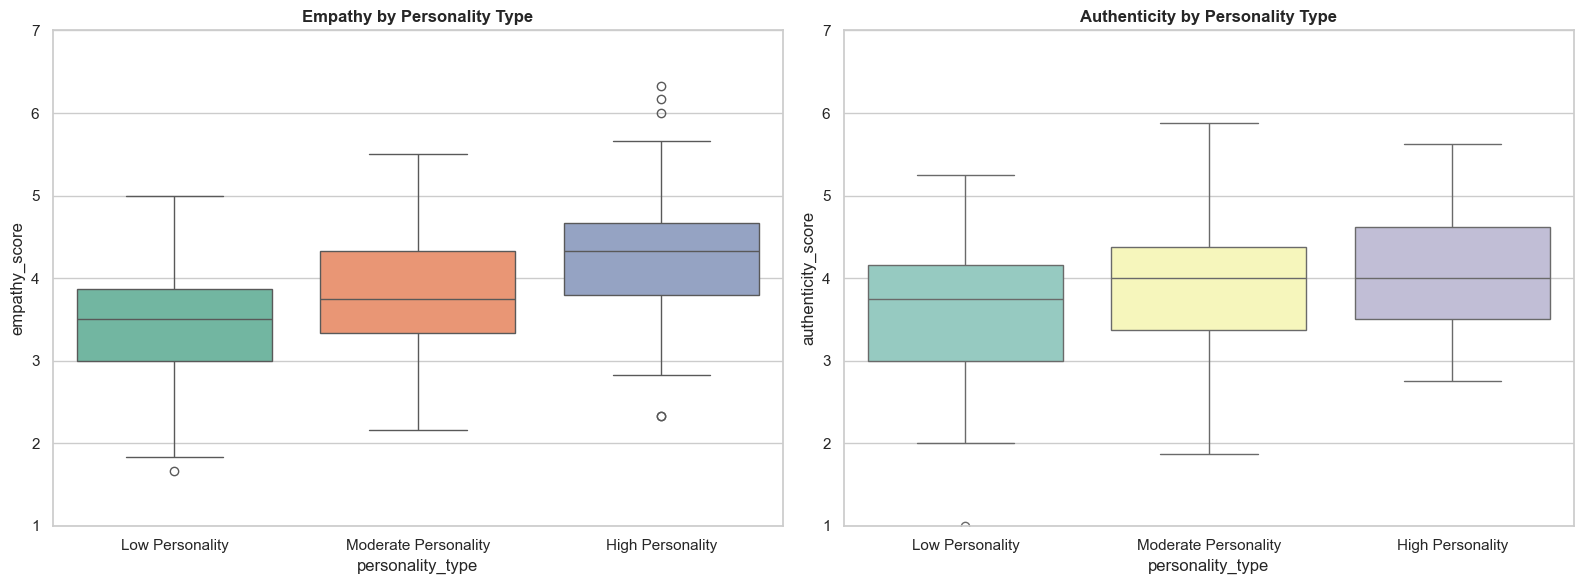

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(data=users, x='personality_type', y='empathy_score', ax=axes[0], palette='Set2',
            order=['Low Personality','Moderate Personality','High Personality'])
axes[0].set_title('Empathy by Personality Type', fontweight='bold'); axes[0].set_ylim(1,7)
sns.boxplot(data=users, x='personality_type', y='authenticity_score', ax=axes[1], palette='Set3',
            order=['Low Personality','Moderate Personality','High Personality'])
axes[1].set_title('Authenticity by Personality Type', fontweight='bold'); axes[1].set_ylim(1,7)
plt.tight_layout()
plt.savefig('/Users/the_irritater/Projects/new_emotional_interaction_chatbot/analysis/obj4_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

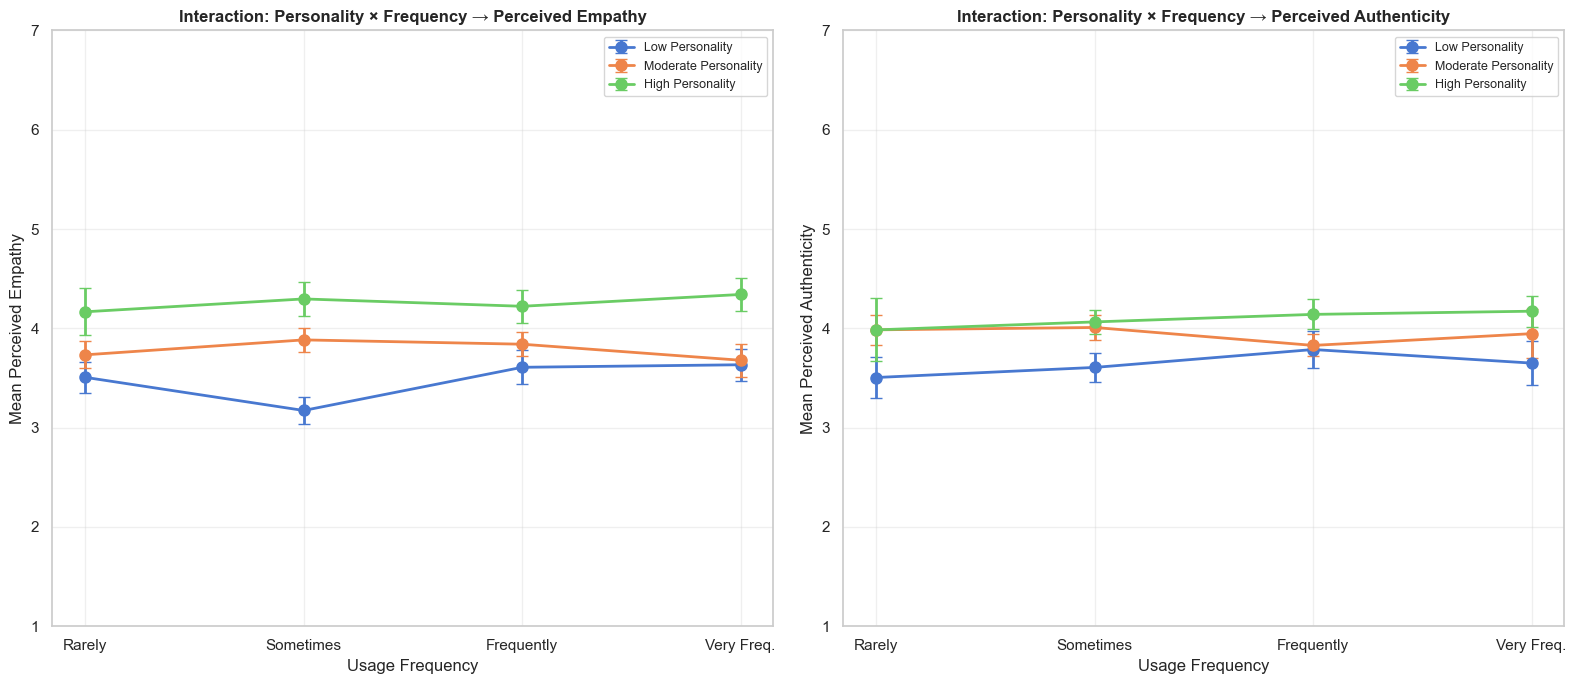

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for idx, (dv, title) in enumerate([('empathy_score','Perceived Empathy'), ('authenticity_score','Perceived Authenticity')]):
    ax = axes[idx]
    for ptype in ['Low Personality','Moderate Personality','High Personality']:
        s = users[users['personality_type']==ptype]
        m = s.groupby('freq_ordinal')[dv].mean(); se = s.groupby('freq_ordinal')[dv].sem()
        ax.errorbar(m.index, m.values, yerr=se.values, marker='o', linewidth=2, markersize=8, capsize=4, label=ptype)
    ax.set_xticks([1,2,3,4]); ax.set_xticklabels(['Rarely','Sometimes','Frequently','Very Freq.'])
    ax.set_xlabel('Usage Frequency'); ax.set_ylabel(f'Mean {title}')
    ax.set_title(f'Interaction: Personality × Frequency → {title}', fontweight='bold')
    ax.legend(fontsize=9); ax.set_ylim(1,7); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/Users/the_irritater/Projects/new_emotional_interaction_chatbot/analysis/obj4_interaction_detail.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. CONCLUSION – Objective 4

### Why Was This Objective Selected?

This objective addresses the **central quality question** of emotional AI: Do users
actually perceive AI as empathetic and authentic? And critically, does this perception
depend on WHO the user is and HOW MUCH they use the system?

1. **Empathy is the promise**: Emotional AI systems are built on the premise that
   they can provide empathetic responses. If perceived empathy varies by personality,
   the system may be failing certain user groups.

2. **Authenticity is the test**: Users who perceive responses as "scripted" or
   "fake" will not sustain engagement. Authenticity perception determines long-term
   adoption viability.

3. **Interaction effects are actionable**: If frequency enhances perceived empathy
   ONLY for certain personality types, AI systems need personality-adaptive engagement
   strategies rather than one-size-fits-all approaches.

4. **Theoretical contribution**: This extends the Technology Acceptance Model by
   adding personality as a moderator of perceived quality in emotional AI contexts.

### What We Aimed to Prove

| Hypothesis | Test | Evidence |
|-----------|------|----------|
| Personality type affects perceived empathy | Two-Way ANOVA (main effect) | F-statistic and p-value |
| Personality type affects perceived authenticity | Two-Way ANOVA (main effect) | F-statistic and p-value |
| Usage frequency affects perceptions | Two-Way ANOVA (main effect) | F-statistic and p-value |
| Personality × Frequency interact | Two-Way ANOVA (interaction) | F-statistic and p-value |
| Continuous prediction is possible | Multiple regression | R² and β coefficients |

### Key Insight
The presence or absence of an interaction effect is the most important finding.
**If the interaction is significant**, it means that simply increasing usage frequency
won't improve perceived quality for everyone — personality-specific strategies are needed.

In [14]:
print("✅ Objective 4 Analysis Complete!")

✅ Objective 4 Analysis Complete!
